# Label Engineering

Builds the weekly label table from general_ema.csv.
All transformation logic is imported from src/ to apply, verify and save the output.

Pipeline:
  load_general_ema
    -> prepare_sse (reverse code sse3-1, compute sse_score)
    -> compute_composite (normalize, invert, average x100)
    -> build_weekly_labels (mean per week)
    -> apply_next_week_shift (W -> W+1 prediction target)
    -> save weekly_labels.csv

Outputs:
  - data/processed/labels/weekly_labels.csv

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path("../../")))

from src.data.loaders import load_general_ema
from src.labels.composite_score import (
    prepare_sse,
    compute_composite,
    build_weekly_labels,
    apply_next_week_shift,
)

DATA_DIR    = Path("../../data/raw/college_experience_dataset")
OUTPUT_DIR  = Path("../../data/processed/labels")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

---
## Load and Classify

In [2]:
EMA_PATH = DATA_DIR / "EMA" / "general_ema.csv"

# load_general_ema applies EXCLUDE_UIDS and classify_ema_rows
df = load_general_ema(str(EMA_PATH))

print(f"Shape              : {df.shape}")
print(f"Students           : {df['uid'].nunique()}")
print(f"Completed responses: {df['has_response'].sum():,}")
print(f"Incomplete surveys : {df['incomplete'].sum():,}")
print(f"No survey rows     : {df['no_survey'].sum():,}")
print(f"Date range         : {df['date'].min().date()} to {df['date'].max().date()}")

Shape              : (217097, 25)
Students           : 216
Completed responses: 35,338
Incomplete surveys : 3,659
No survey rows     : 178,100
Date range         : 2017-09-07 to 2022-07-04


---
## SSE Preparation

Reverse codes sse3-1 (6 - score) and computes the SSE sum score.

In [6]:
df = prepare_sse(df)

print("SSE preparation complete.")
print(f"sse3-1_r sample (first 5): {df['sse3-1_r'].dropna().head().tolist()}")
print(f"sse_score range: {df['sse_score'].min():.0f} to {df['sse_score'].max():.0f}")
print(f"Expected range : 4 to 20")

# Sanity check: sse3-1 + sse3-1_r should always equal 6
check = (df['sse3-1'] + df['sse3-1_r']).dropna()
n_wrong = (check != 6).sum()
if n_wrong > 0:
    print(f"WARNING: {n_wrong} rows where sse3-1 + sse3-1_r != 6")
    print(df[check != 6][['sse3-1', 'sse3-1_r']].head())
else:
    print("Verified: sse3-1 + sse3-1_r = 6 for all non-null rows.")

SSE preparation complete.
sse3-1_r sample (first 5): [5.0, 4.0, 5.0, 5.0, 5.0]
sse_score range: 4 to 20
Expected range : 4 to 20
Verified: sse3-1 + sse3-1_r = 6 for all non-null rows.


---
## Composite Score

Normalizes all four instruments to [0, 1], inverts negative indicators
(PHQ4, stress), averages equally, multiplies by 100.
Any row missing one or more instruments produces NaN.

Rows with composite score : 35,338
Rows with NaN composite   : 181,759

Distribution:
count    35338.00
mean        63.16
std         16.92
min          0.00
25%         52.60
50%         64.06
75%         75.00
max        100.00
Name: composite_score, dtype: float64


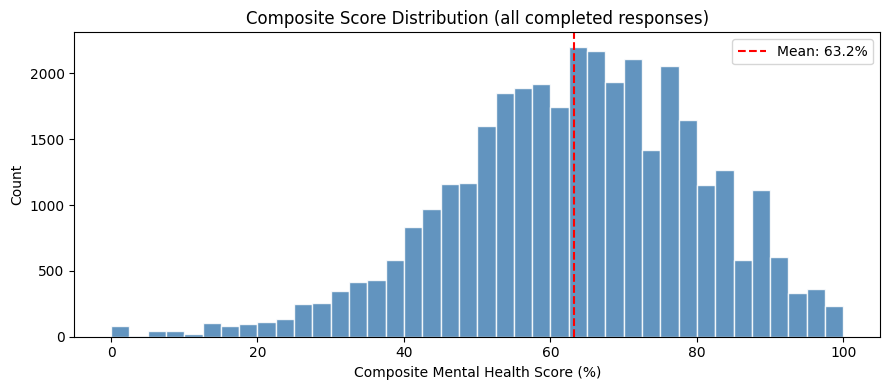

In [7]:
df["composite_score"] = compute_composite(df)

valid = df["composite_score"].dropna()
print(f"Rows with composite score : {len(valid):,}")
print(f"Rows with NaN composite   : {df['composite_score'].isna().sum():,}")
print(f"\nDistribution:")
print(valid.describe().round(2))

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(valid, bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(valid.mean(), color="red", linestyle="--",
           label=f"Mean: {valid.mean():.1f}%")
ax.set_title("Composite Score Distribution (all completed responses)")
ax.set_xlabel("Composite Mental Health Score (%)")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.savefig("../../outputs/figures/label_composite_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

---
## Weekly Label Aggregation

Aggregates daily composite scores to one label per (student, ISO week) using the mean. Only completed survey rows are included.

In [5]:
weekly = build_weekly_labels(df)

print(f"Weekly label rows  : {len(weekly):,}")
print(f"Students           : {weekly['uid'].nunique()}")
print(f"ISO weeks covered  : {weekly['year_week'].nunique()}")
print(f"Date range         : {weekly['year_week'].min()} to {weekly['year_week'].max()}")
print(f"\nSurveys per week distribution:")
print(weekly["n_surveys_in_week"].value_counts().sort_index())

Weekly label rows  : 24,397
Students           : 216
ISO weeks covered  : 252
Date range         : 2017-W36 to 2022-W26

Surveys per week distribution:
n_surveys_in_week
1    15838
2     6440
3     1867
4      242
5        9
6        1
Name: count, dtype: int64


---
## Next-Week Shift

Applies the W -> W+1 prediction shift.
The label for feature week W is the composite score observed in week W+1.
Weeks where W+1 has no EMA survey are dropped.

In [8]:
labels = apply_next_week_shift(weekly)

print(f"Usable training examples : {len(labels):,}")
print(f"Students represented     : {labels['uid'].nunique()}")
print(f"Feature week range       : {labels['feature_week'].min()} to {labels['feature_week'].max()}")
print(f"\nColumns: {list(labels.columns)}")
print(f"\nSample rows:")
print(labels.head(8).to_string(index=False))

Usable training examples : 20,193
Students represented     : 216
Feature week range       : 2017-W36 to 2022-W25

Columns: ['uid', 'feature_week', 'label_week', 'label_composite_score', 'n_surveys_in_week']

Sample rows:
                             uid feature_week label_week  label_composite_score  n_surveys_in_week
003df5deff30e1e5a07b5d063fe85c3f     2017-W40   2017-W41                92.1875                  1
003df5deff30e1e5a07b5d063fe85c3f     2017-W41   2017-W42                70.3125                  2
003df5deff30e1e5a07b5d063fe85c3f     2017-W42   2017-W43                76.5625                  1
003df5deff30e1e5a07b5d063fe85c3f     2017-W43   2017-W44                82.8125                  1
003df5deff30e1e5a07b5d063fe85c3f     2017-W44   2017-W45                64.0625                  1
003df5deff30e1e5a07b5d063fe85c3f     2017-W45   2017-W46                71.3542                  2
003df5deff30e1e5a07b5d063fe85c3f     2017-W48   2017-W49                95.3125       

---
## Student Count Verification

Traces exactly where students are lost between load and final label table.
Expected: 216 after exclusions. Final training population lower due to sensing join and next-week shift (investigated further in assembly notebook).

In [9]:
n_loaded   = df["uid"].nunique()
n_weekly   = weekly["uid"].nunique()
n_labels   = labels["uid"].nunique()

print("Student count at each step:")
print(f"  After load_general_ema (EXCLUDE_UIDS applied) : {n_loaded}")
print(f"  After build_weekly_labels                      : {n_weekly}")
print(f"  After apply_next_week_shift                    : {n_labels}")
print()

# Students lost at weekly aggregation step
lost_at_weekly = set(df["uid"].unique()) - set(weekly["uid"].unique())
print(f"Lost at weekly aggregation: {len(lost_at_weekly)}")
if lost_at_weekly:
    for uid in lost_at_weekly:
        rows = df[df["uid"] == uid]
        print(f"  {uid}: {rows['has_response'].sum()} completed responses")

# Students lost at shift step
lost_at_shift = set(weekly["uid"].unique()) - set(labels["uid"].unique())
print(f"\nLost at next-week shift: {len(lost_at_shift)}")
if lost_at_shift:
    for uid in lost_at_shift:
        wks = weekly[weekly["uid"] == uid]["year_week"].tolist()
        print(f"  {uid}: {len(wks)} weekly labels, weeks: {wks}")
        print(f"  Reason: only 1 week of data, no W+1 label exists")

# Split pre-COVID / post-COVID
pre_covid  = labels[labels["feature_week"] < "2020-W12"]
post_covid = labels[labels["feature_week"] >= "2020-W12"]

print(f"\nPre-COVID examples  (v1 training pool) : {len(pre_covid):,}")
print(f"Post-COVID examples (drift period)     : {len(post_covid):,}")
print(f"Pre-COVID students                     : {pre_covid['uid'].nunique()}")

Student count at each step:
  After load_general_ema (EXCLUDE_UIDS applied) : 216
  After build_weekly_labels                      : 216
  After apply_next_week_shift                    : 216

Lost at weekly aggregation: 0

Lost at next-week shift: 0

Pre-COVID examples  (v1 training pool) : 12,565
Post-COVID examples (drift period)     : 7,628
Pre-COVID students                     : 216


---
### Save

In [10]:
out_path = OUTPUT_DIR / "weekly_labels.csv"
labels.to_csv(out_path, index=False)

print(f"Saved: {out_path}")
print(f"Rows  : {len(labels):,}")
print(f"Size  : {out_path.stat().st_size / 1024:.1f} KB")
print(f"\nColumns:")
for col in labels.columns:
    print(f"  {col}: {labels[col].dtype}")

Saved: ..\..\data\processed\labels\weekly_labels.csv
Rows  : 20,193
Size  : 1215.2 KB

Columns:
  uid: str
  feature_week: str
  label_week: str
  label_composite_score: float64
  n_surveys_in_week: int64
